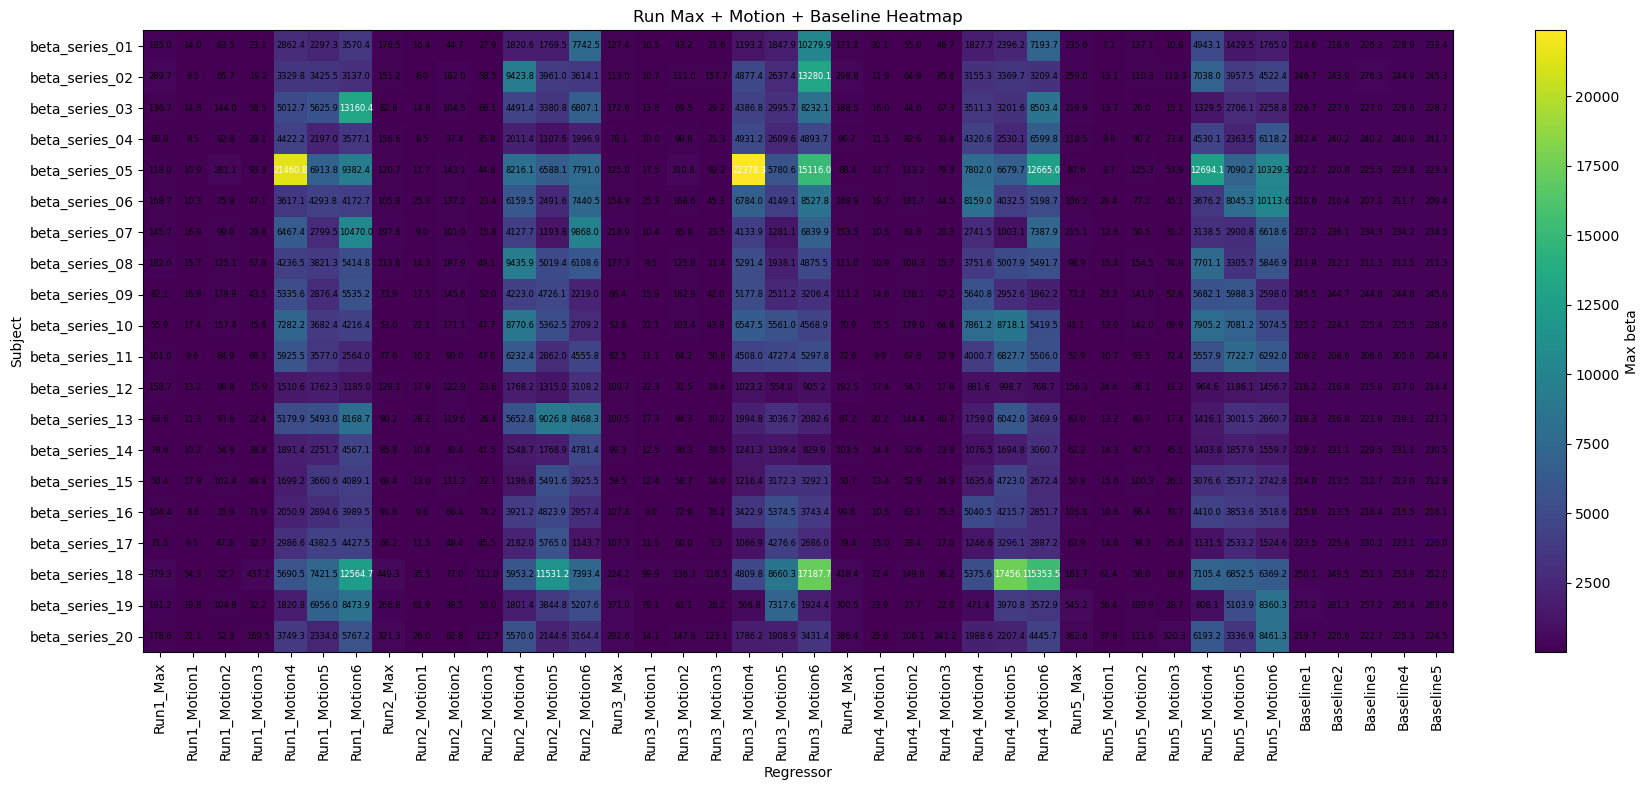

In [4]:
import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
dataDir = r"N:\Experimental_Data\Ke Bo\Project_IAPS\fMRI\code\fMRI\Newbeta_series"

subs = [f"beta_series_{i:02d}" for i in range(1, 21)]

n_runs = 5
n_trials = 60
n_motion = 6
n_baseline = 5

annotate_values = True
annotate_fontsize = 6


# ============================================================
# HELPERS
# ============================================================
def get_beta_files(sub_path):
    files = [
        f for f in os.listdir(sub_path)
        if re.match(r"beta_\d+.*\.(nii|nii\.gz|img)$", f)
    ]

    files = sorted(files, key=lambda x: int(re.search(r"beta_(\d+)", x).group(1)))
    return [os.path.join(sub_path, f) for f in files]


def max_beta(file):
    img = nib.load(file)
    return float(np.nanmax(img.get_fdata()))


# ============================================================
# EXTRACT DATA
# ============================================================
rows = []

for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    beta_files = get_beta_files(sub_path)

    for run in range(1, n_runs + 1):

        run_start = (run - 1) * (n_trials + n_motion)

        # =========================
        # MAX TRIAL PER RUN
        # =========================
        trial_indices = list(range(run_start, run_start + n_trials))

        trial_vals = [max_beta(beta_files[i]) for i in trial_indices]
        run_max = max(trial_vals)

        rows.append({
            "subject": sub,
            "category": f"Run{run}_Max",
            "value": run_max
        })

        # =========================
        # MOTION (keep all 6)
        # =========================
        for m in range(1, n_motion + 1):
            idx = run_start + n_trials + (m - 1)

            rows.append({
                "subject": sub,
                "category": f"Run{run}_Motion{m}",
                "value": max_beta(beta_files[idx])
            })

    # =========================
    # BASELINE (last 5)
    # =========================
    baseline_start = n_runs * (n_trials + n_motion)

    for b in range(1, n_baseline + 1):
        idx = baseline_start + (b - 1)

        rows.append({
            "subject": sub,
            "category": f"Baseline{b}",
            "value": max_beta(beta_files[idx])
        })


df = pd.DataFrame(rows)


# ============================================================
# HEATMAP
# ============================================================
heatmap_df = df.pivot(index="subject", columns="category", values="value")
heatmap_df = heatmap_df.loc[subs]

# enforce column order
category_order = df["category"].drop_duplicates().tolist()
heatmap_df = heatmap_df[category_order]

plt.figure(figsize=(18, 8))

im = plt.imshow(heatmap_df.values, aspect="auto")

plt.colorbar(im, label="Max beta")

plt.yticks(np.arange(len(subs)), subs)
plt.xticks(np.arange(len(category_order)), category_order, rotation=90)

plt.xlabel("Regressor")
plt.ylabel("Subject")
plt.title("Run Max + Motion + Baseline Heatmap")


# ============================================================
# ADD VALUES INTO CELLS
# ============================================================
if annotate_values:
    values = heatmap_df.values
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    threshold = (vmin + vmax) / 2

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isnan(val):
                continue

            color = "white" if val > threshold else "black"

            plt.text(
                j, i,
                f"{val:.1f}",
                ha="center",
                va="center",
                color=color,
                fontsize=annotate_fontsize
            )

plt.tight_layout()
plt.savefig("run_max_motion_baseline_heatmap.png", dpi=300)
plt.show()

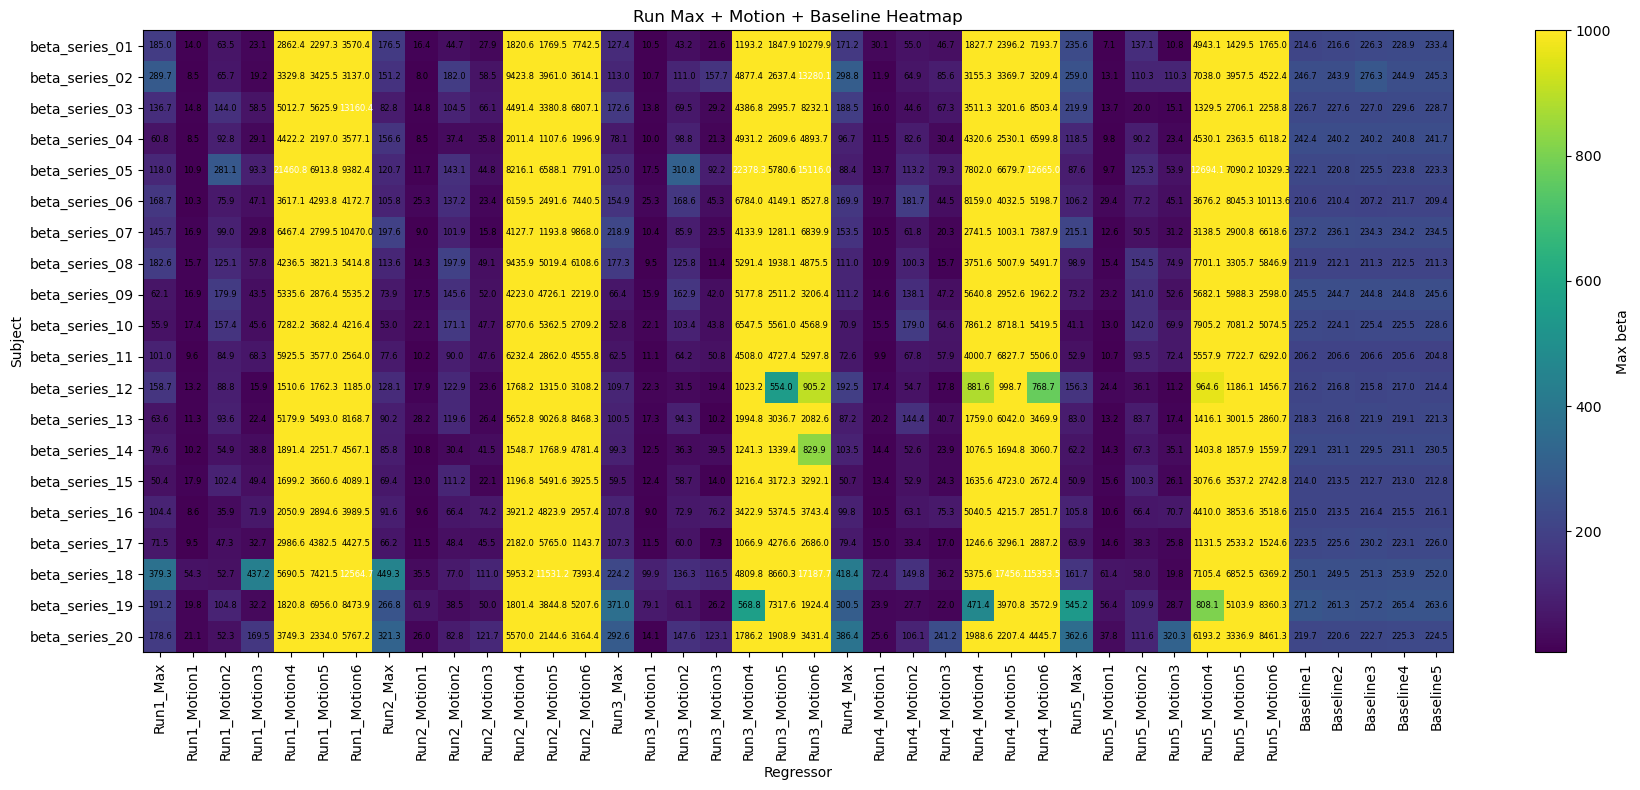

In [6]:
# ============================================================
# HEATMAP
# ============================================================
heatmap_df = df.pivot(index="subject", columns="category", values="value")
heatmap_df = heatmap_df.loc[subs]

# enforce column order
category_order = df["category"].drop_duplicates().tolist()
heatmap_df = heatmap_df[category_order]

plt.figure(figsize=(18, 8))

im = plt.imshow(
    heatmap_df.values,
    aspect="auto",
    vmin=np.nanmin(values),
    vmax=1000   # <-- controls color contrast
)

plt.colorbar(im, label="Max beta")

plt.yticks(np.arange(len(subs)), subs)
plt.xticks(np.arange(len(category_order)), category_order, rotation=90)

plt.xlabel("Regressor")
plt.ylabel("Subject")
plt.title("Run Max + Motion + Baseline Heatmap")


# ============================================================
# ADD VALUES INTO CELLS
# ============================================================
if annotate_values:
    values = heatmap_df.values
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    threshold = (vmin + vmax) / 2

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isnan(val):
                continue

            color = "white" if val > threshold else "black"

            plt.text(
                j, i,
                f"{val:.1f}",
                ha="center",
                va="center",
                color=color,
                fontsize=annotate_fontsize
            )

plt.tight_layout()
plt.savefig("run_max_motion_baseline_heatmap.png", dpi=300)
plt.show()

In [9]:
import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


# ============================================================
# SETTINGS
# ============================================================
beta_dir = r"N:\Experimental_Data\Ke Bo\Project_IAPS\fMRI\code\fMRI\Newbeta_series"
roi_dir  = r"N:\Experimental_Data\Ke Bo\Project_IAPS\fMRI\roi\new"

subs = [f"beta_series_{i:02d}" for i in range(1, 21)]

N_FOLDS = 5
RANDOM_STATE = 42

comparison_name = "pleasant_vs_neutral"


# ============================================================
# LOAD ROI MASKS
# ============================================================
kastner_l = nib.load(os.path.join(roi_dir, "maxprob_vol_lh.nii"))
kastner_r = nib.load(os.path.join(roi_dir, "maxprob_vol_rh.nii"))

kastner_combine = kastner_l.get_fdata() + kastner_r.get_fdata()
kastner_combine_nii = nib.Nifti1Image(kastner_combine, kastner_l.affine)

print("ROI atlas shape:", kastner_combine_nii.shape)

roi_labels = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d',
    'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2',
    'MST', 'hMT', 'LO2', 'LO1', 'V3b', 'V3a',
    'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5',
    'SPL1', 'FEF'
]

roi_masks = {}
combined_IPS_mask = np.zeros(kastner_combine_nii.shape, dtype=bool)

for label_id, roi_name in enumerate(roi_labels, start=1):

    if roi_name in ['MST', 'SPL1', 'FEF']:
        continue

    if 'IPS' in roi_name:
        combined_IPS_mask |= (kastner_combine == label_id)
    else:
        roi_mask_data = (kastner_combine == label_id).astype(np.uint8)
        roi_mask_img = nib.Nifti1Image(
            roi_mask_data,
            affine=kastner_l.affine,
            dtype=np.uint8
        )
        roi_mask_img.header.set_data_dtype(np.uint8)
        roi_masks[roi_name] = roi_mask_img

if combined_IPS_mask.any():
    ips_mask_u8 = combined_IPS_mask.astype(np.uint8)
    ips_img = nib.Nifti1Image(
        ips_mask_u8,
        affine=kastner_l.affine,
        dtype=np.uint8
    )
    ips_img.header.set_data_dtype(np.uint8)
    roi_masks["IPS"] = ips_img

print("\nROIs loaded:")
for roi_name, roi_img in roi_masks.items():
    print(
        roi_name,
        roi_img.get_fdata().shape,
        np.count_nonzero(roi_img.get_fdata())
    )


# ============================================================
# HELPERS
# ============================================================
def get_beta_files(sub_path):
    files = [
        f for f in os.listdir(sub_path)
        if re.match(r"beta_\d+.*\.(nii|nii\.gz|img)$", f)
    ]

    files = sorted(
        files,
        key=lambda x: int(re.search(r"beta_(\d+)", x).group(1))
    )

    return [os.path.join(sub_path, f) for f in files]


def load_beta_flat(beta_file):
    img = nib.load(beta_file)
    data = img.get_fdata(dtype=np.float32)

    if data.shape != kastner_combine_nii.shape:
        raise ValueError(
            f"Shape mismatch: beta shape {data.shape}, ROI shape {kastner_combine_nii.shape}"
        )

    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    return data.ravel()


def get_pl_nt_beta_indices():
    """
    0-based beta indices.

    Per run:
    beta 1-20   = Pleasant
    beta 21-40  = Neutral
    beta 41-60  = Unpleasant
    beta 61-66  = Motion

    5 runs total.
    Constants are beta 331-335 and are ignored.
    """
    pl_indices = []
    nt_indices = []

    for run in range(5):
        run_start = run * 66

        pl_indices.extend(range(run_start + 0,  run_start + 20))
        nt_indices.extend(range(run_start + 20, run_start + 40))

    return pl_indices, nt_indices


pl_indices, nt_indices = get_pl_nt_beta_indices()


# ============================================================
# DECODING
# ============================================================
all_results = []

total_iterations = len(roi_masks) * len(subs)

with tqdm(total=total_iterations, desc="ROI decoding") as pbar:

    for roi_name, roi_img in roi_masks.items():

        roi_bool = roi_img.get_fdata().astype(bool).ravel()
        vox_idx = np.where(roi_bool)[0]

        if vox_idx.size == 0:
            print(f"Skipping empty ROI: {roi_name}")
            continue

        for sub in subs:

            sub_path = os.path.join(beta_dir, sub)
            beta_files = get_beta_files(sub_path)

            if len(beta_files) != 335:
                raise ValueError(
                    f"{sub} has {len(beta_files)} beta files, expected 335"
                )

            X = []
            y = []

            # Pleasant = 1
            for idx in pl_indices:
                beta_flat = load_beta_flat(beta_files[idx])
                X.append(beta_flat[vox_idx])
                y.append(1)

            # Neutral = 0
            for idx in nt_indices:
                beta_flat = load_beta_flat(beta_files[idx])
                X.append(beta_flat[vox_idx])
                y.append(0)

            X = np.asarray(X, dtype=np.float32)
            y = np.asarray(y, dtype=int)

            X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

            skf = StratifiedKFold(
                n_splits=N_FOLDS,
                shuffle=True,
                random_state=RANDOM_STATE
            )

            fold_accs = []

            for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                clf = LinearSVC(
                    C=1.0,
                    max_iter=50000,
                    dual="auto",
                    random_state=RANDOM_STATE
                )

                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                fold_accs.append(acc)

                all_results.append({
                    "comparison": comparison_name,
                    "roi": roi_name,
                    "subject": sub,
                    "fold": fold,
                    "accuracy": acc,
                    "n_voxels": len(vox_idx),
                    "n_samples": X.shape[0]
                })

            pbar.update(1)


# ============================================================
# SAVE RESULTS
# ============================================================
results_df = pd.DataFrame(all_results)

results_df.to_csv(
    "kebo_roi_decoding_pleasant_vs_neutral_5fold.csv",
    index=False
)

subject_roi_df = (
    results_df
    .groupby(["comparison", "roi", "subject"], as_index=False)
    .agg(mean_accuracy=("accuracy", "mean"))
)

summary_df = (
    subject_roi_df
    .groupby(["comparison", "roi"], as_index=False)
    .agg(
        mean_accuracy=("mean_accuracy", "mean"),
        std_accuracy=("mean_accuracy", "std"),
        n_subjects=("subject", "nunique")
    )
)

summary_df["sem_accuracy"] = (
    summary_df["std_accuracy"] / np.sqrt(summary_df["n_subjects"])
)

summary_df.to_csv(
    "kebo_roi_decoding_pleasant_vs_neutral_summary.csv",
    index=False
)

print("\nDECODING COMPLETE!")
print(summary_df)

ROI atlas shape: (53, 63, 46)

ROIs loaded:
V1v (53, 63, 46) 246
V1d (53, 63, 46) 227
V2v (53, 63, 46) 217
V2d (53, 63, 46) 199
V3v (53, 63, 46) 147
V3d (53, 63, 46) 149
hV4 (53, 63, 46) 105
VO1 (53, 63, 46) 42
VO2 (53, 63, 46) 74
PHC1 (53, 63, 46) 52
PHC2 (53, 63, 46) 52
hMT (53, 63, 46) 32
LO2 (53, 63, 46) 38
LO1 (53, 63, 46) 99
V3b (53, 63, 46) 73
V3a (53, 63, 46) 174
IPS (53, 63, 46) 295


ROI decoding: 100%|██████████| 340/340 [2:10:01<00:00, 22.95s/it]  



DECODING COMPLETE!
             comparison   roi  mean_accuracy  std_accuracy  n_subjects  \
0   pleasant_vs_neutral   IPS        0.59475      0.053076          20   
1   pleasant_vs_neutral   LO1        0.59400      0.066681          20   
2   pleasant_vs_neutral   LO2        0.61875      0.042639          20   
3   pleasant_vs_neutral  PHC1        0.55300      0.042686          20   
4   pleasant_vs_neutral  PHC2        0.52150      0.063206          20   
5   pleasant_vs_neutral   V1d        0.56950      0.039300          20   
6   pleasant_vs_neutral   V1v        0.57175      0.046518          20   
7   pleasant_vs_neutral   V2d        0.56000      0.045131          20   
8   pleasant_vs_neutral   V2v        0.56675      0.039312          20   
9   pleasant_vs_neutral   V3a        0.57850      0.061923          20   
10  pleasant_vs_neutral   V3b        0.59350      0.058918          20   
11  pleasant_vs_neutral   V3d        0.56900      0.054231          20   
12  pleasant_vs_ne

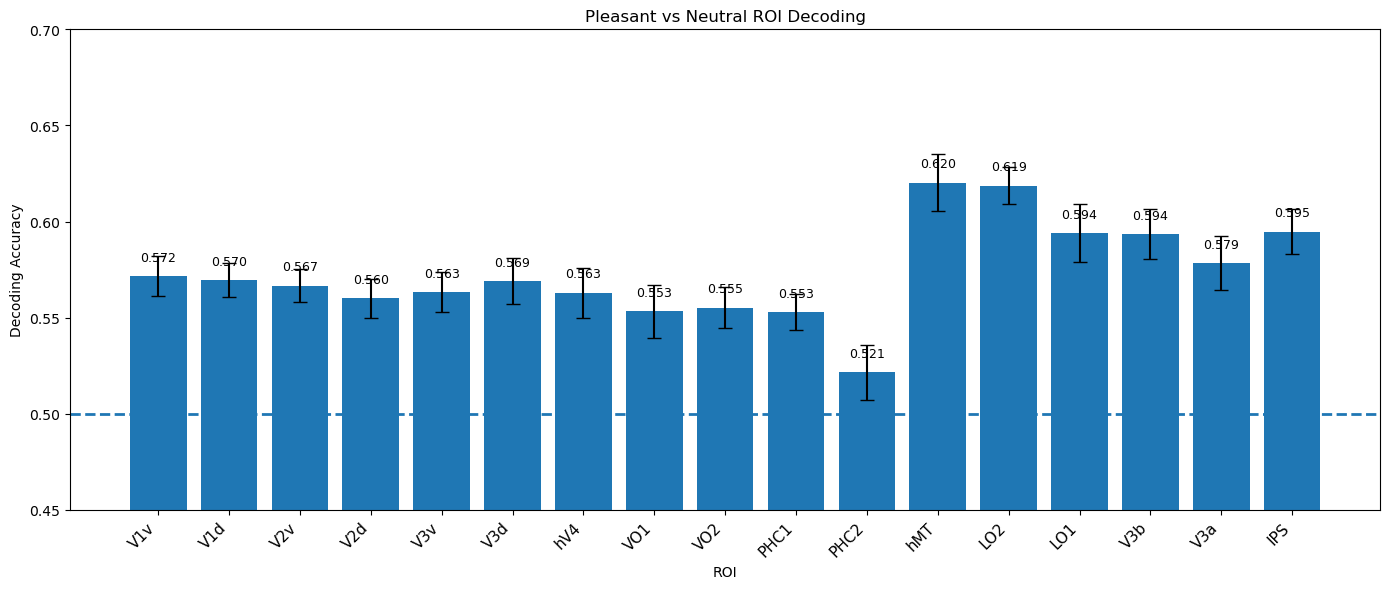

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ORIGINAL ROI ORDER
# ============================================================
roi_order = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d',
    'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2',
    'hMT', 'LO2', 'LO1', 'V3b', 'V3a',
    'IPS'
]

# ============================================================
# REORDER DATAFRAME
# ============================================================
plot_df = (
    summary_df
    .set_index("roi")
    .loc[roi_order]
    .reset_index()
)

# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(14, 6))

x = np.arange(len(plot_df))

plt.bar(
    x,
    plot_df["mean_accuracy"],
    yerr=plot_df["sem_accuracy"],
    capsize=5
)

# Chance line
plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2
)

# X labels
plt.xticks(
    x,
    plot_df["roi"],
    rotation=45,
    ha="right",
    fontsize=11
)

plt.ylabel("Decoding Accuracy")
plt.xlabel("ROI")
plt.title("Pleasant vs Neutral ROI Decoding")

# ============================================================
# ADD ACCURACY VALUES
# ============================================================
for i, row in enumerate(plot_df.itertuples()):

    plt.text(
        i,
        row.mean_accuracy + 0.008,
        f"{row.mean_accuracy:.3f}",
        ha="center",
        fontsize=9
    )

plt.ylim(0.45, 0.70)

plt.tight_layout()

plt.savefig(
    "pleasant_vs_neutral_roi_decoding_ordered.png",
    dpi=300
)

plt.show()

ROI atlas shape: (53, 63, 46)

ROIs loaded:
V1v (53, 63, 46) 246
V1d (53, 63, 46) 227
V2v (53, 63, 46) 217
V2d (53, 63, 46) 199
V3v (53, 63, 46) 147
V3d (53, 63, 46) 149
hV4 (53, 63, 46) 105
VO1 (53, 63, 46) 42
VO2 (53, 63, 46) 74
PHC1 (53, 63, 46) 52
PHC2 (53, 63, 46) 52
hMT (53, 63, 46) 32
LO2 (53, 63, 46) 38
LO1 (53, 63, 46) 99
V3b (53, 63, 46) 73
V3a (53, 63, 46) 174
IPS (53, 63, 46) 295

Number of unpleasant trials: 100
Number of neutral trials: 100
First few unpleasant beta indices, 0-based: [40, 41, 42, 43, 44]
First few neutral beta indices, 0-based: [20, 21, 22, 23, 24]


ROI decoding: 100%|██████████| 340/340 [2:57:40<00:00, 31.36s/it]  



DECODING COMPLETE!
               comparison   roi  mean_accuracy  std_accuracy  n_subjects  \
0   unpleasant_vs_neutral   IPS        0.62775      0.063047          20   
1   unpleasant_vs_neutral   LO1        0.61800      0.054202          20   
2   unpleasant_vs_neutral   LO2        0.60075      0.051994          20   
3   unpleasant_vs_neutral  PHC1        0.61175      0.048647          20   
4   unpleasant_vs_neutral  PHC2        0.56175      0.058966          20   
5   unpleasant_vs_neutral   V1d        0.62050      0.057877          20   
6   unpleasant_vs_neutral   V1v        0.63150      0.055491          20   
7   unpleasant_vs_neutral   V2d        0.60525      0.063525          20   
8   unpleasant_vs_neutral   V2v        0.61725      0.054131          20   
9   unpleasant_vs_neutral   V3a        0.60425      0.060487          20   
10  unpleasant_vs_neutral   V3b        0.61975      0.067268          20   
11  unpleasant_vs_neutral   V3d        0.61225      0.063815        

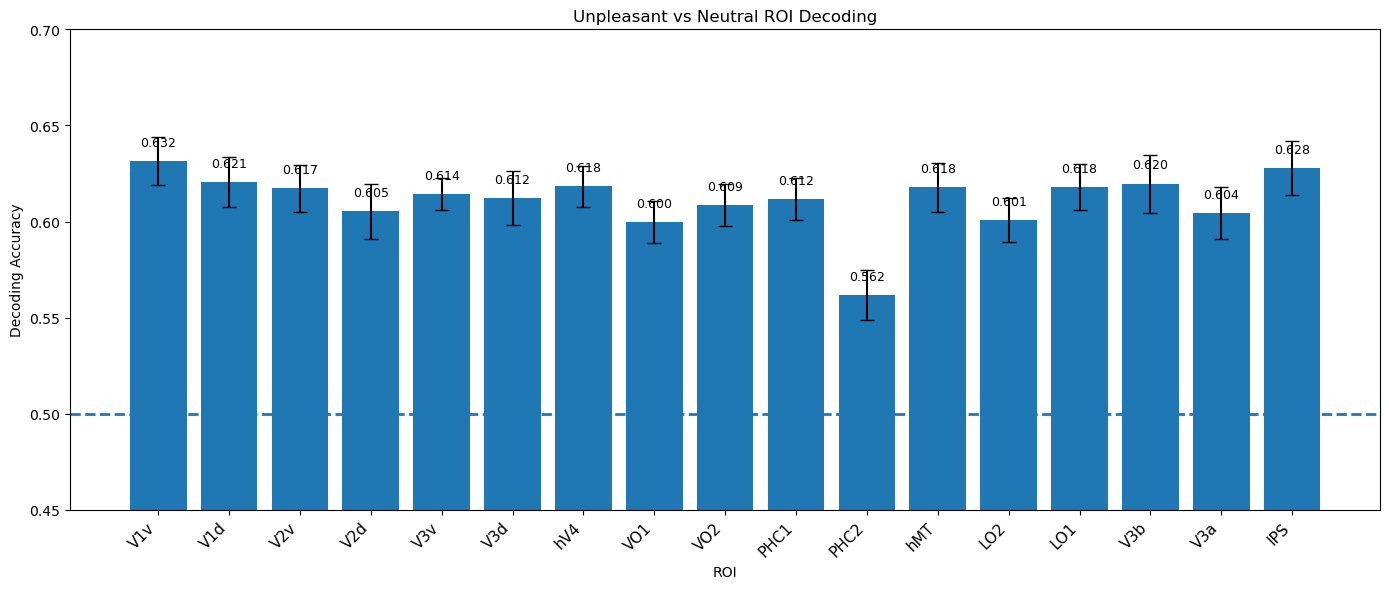

In [16]:
import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


# ============================================================
# SETTINGS
# ============================================================
beta_dir = r"N:\Experimental_Data\Ke Bo\Project_IAPS\fMRI\code\fMRI\Newbeta_series"
roi_dir  = r"N:\Experimental_Data\Ke Bo\Project_IAPS\fMRI\roi\new"

subs = [f"beta_series_{i:02d}" for i in range(1, 21)]

N_FOLDS = 5
RANDOM_STATE = 42

comparison_name = "unpleasant_vs_neutral"


# ============================================================
# LOAD ROI MASKS
# ============================================================
kastner_l = nib.load(os.path.join(roi_dir, "maxprob_vol_lh.nii"))
kastner_r = nib.load(os.path.join(roi_dir, "maxprob_vol_rh.nii"))

kastner_combine = kastner_l.get_fdata() + kastner_r.get_fdata()
kastner_combine_nii = nib.Nifti1Image(kastner_combine, kastner_l.affine)

print("ROI atlas shape:", kastner_combine_nii.shape)

roi_labels = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d',
    'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2',
    'MST', 'hMT', 'LO2', 'LO1', 'V3b', 'V3a',
    'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5',
    'SPL1', 'FEF'
]

roi_masks = {}
combined_IPS_mask = np.zeros(kastner_combine_nii.shape, dtype=bool)

for label_id, roi_name in enumerate(roi_labels, start=1):

    if roi_name in ['MST', 'SPL1', 'FEF']:
        continue

    if 'IPS' in roi_name:
        combined_IPS_mask |= (kastner_combine == label_id)
    else:
        roi_mask_data = (kastner_combine == label_id).astype(np.uint8)

        roi_mask_img = nib.Nifti1Image(
            roi_mask_data,
            affine=kastner_l.affine,
            dtype=np.uint8
        )

        roi_mask_img.header.set_data_dtype(np.uint8)
        roi_masks[roi_name] = roi_mask_img

if combined_IPS_mask.any():
    ips_mask_u8 = combined_IPS_mask.astype(np.uint8)

    ips_img = nib.Nifti1Image(
        ips_mask_u8,
        affine=kastner_l.affine,
        dtype=np.uint8
    )

    ips_img.header.set_data_dtype(np.uint8)
    roi_masks["IPS"] = ips_img


print("\nROIs loaded:")
for roi_name, roi_img in roi_masks.items():
    print(
        roi_name,
        roi_img.get_fdata().shape,
        np.count_nonzero(roi_img.get_fdata())
    )


# ============================================================
# HELPERS
# ============================================================
def get_beta_files(sub_path):
    files = [
        f for f in os.listdir(sub_path)
        if re.match(r"beta_\d+.*\.(nii|nii\.gz|img)$", f)
    ]

    files = sorted(
        files,
        key=lambda x: int(re.search(r"beta_(\d+)", x).group(1))
    )

    return [os.path.join(sub_path, f) for f in files]


def load_beta_flat(beta_file):
    img = nib.load(beta_file)
    data = img.get_fdata(dtype=np.float32)

    if data.shape != kastner_combine_nii.shape:
        raise ValueError(
            f"Shape mismatch: beta shape {data.shape}, "
            f"ROI shape {kastner_combine_nii.shape}"
        )

    data = np.nan_to_num(
        data,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return data.ravel()


def get_up_nt_beta_indices():
    """
    0-based beta indices.

    Per run:
    beta 1-20   = Pleasant
    beta 21-40  = Neutral
    beta 41-60  = Unpleasant
    beta 61-66  = Motion

    5 runs total.
    Constants beta 331-335 are ignored.
    """
    up_indices = []
    nt_indices = []

    for run in range(5):
        run_start = run * 66

        # Neutral: beta 21-40 within each run
        nt_indices.extend(
            range(run_start + 20, run_start + 40)
        )

        # Unpleasant: beta 41-60 within each run
        up_indices.extend(
            range(run_start + 40, run_start + 60)
        )

    return up_indices, nt_indices


up_indices, nt_indices = get_up_nt_beta_indices()

print("\nNumber of unpleasant trials:", len(up_indices))
print("Number of neutral trials:", len(nt_indices))

print("First few unpleasant beta indices, 0-based:", up_indices[:5])
print("First few neutral beta indices, 0-based:", nt_indices[:5])


# ============================================================
# DECODING: UNPLEASANT VS NEUTRAL
# ============================================================
all_results = []

total_iterations = len(roi_masks) * len(subs)

with tqdm(total=total_iterations, desc="ROI decoding") as pbar:

    for roi_name, roi_img in roi_masks.items():

        roi_bool = roi_img.get_fdata().astype(bool).ravel()
        vox_idx = np.where(roi_bool)[0]

        if vox_idx.size == 0:
            print(f"Skipping empty ROI: {roi_name}")
            continue

        for sub in subs:

            sub_path = os.path.join(beta_dir, sub)
            beta_files = get_beta_files(sub_path)

            if len(beta_files) != 335:
                raise ValueError(
                    f"{sub} has {len(beta_files)} beta files, expected 335"
                )

            X = []
            y = []

            # ====================================================
            # Unpleasant = 1
            # ====================================================
            for idx in up_indices:
                beta_flat = load_beta_flat(beta_files[idx])
                X.append(beta_flat[vox_idx])
                y.append(1)

            # ====================================================
            # Neutral = 0
            # ====================================================
            for idx in nt_indices:
                beta_flat = load_beta_flat(beta_files[idx])
                X.append(beta_flat[vox_idx])
                y.append(0)

            X = np.asarray(X, dtype=np.float32)
            y = np.asarray(y, dtype=int)

            X = np.nan_to_num(
                X,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            skf = StratifiedKFold(
                n_splits=N_FOLDS,
                shuffle=True,
                random_state=RANDOM_STATE
            )

            fold_accs = []

            for fold, (train_idx, test_idx) in enumerate(
                skf.split(X, y),
                start=1
            ):

                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                clf = LinearSVC(
                    C=1.0,
                    max_iter=50000,
                    dual="auto",
                    random_state=RANDOM_STATE
                )

                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                fold_accs.append(acc)

                all_results.append({
                    "comparison": comparison_name,
                    "roi": roi_name,
                    "subject": sub,
                    "fold": fold,
                    "accuracy": acc,
                    "n_voxels": len(vox_idx),
                    "n_samples": X.shape[0]
                })

            pbar.update(1)


# ============================================================
# SAVE RESULTS
# ============================================================
results_df = pd.DataFrame(all_results)

results_df.to_csv(
    "kebo_roi_decoding_unpleasant_vs_neutral_5fold.csv",
    index=False
)

subject_roi_df = (
    results_df
    .groupby(["comparison", "roi", "subject"], as_index=False)
    .agg(mean_accuracy=("accuracy", "mean"))
)

summary_df = (
    subject_roi_df
    .groupby(["comparison", "roi"], as_index=False)
    .agg(
        mean_accuracy=("mean_accuracy", "mean"),
        std_accuracy=("mean_accuracy", "std"),
        n_subjects=("subject", "nunique")
    )
)

summary_df["sem_accuracy"] = (
    summary_df["std_accuracy"] / np.sqrt(summary_df["n_subjects"])
)

summary_df.to_csv(
    "kebo_roi_decoding_unpleasant_vs_neutral_summary.csv",
    index=False
)

print("\nDECODING COMPLETE!")
print(summary_df)


# ============================================================
# PLOT RESULT IN ROI ORDER
# ============================================================
import matplotlib.pyplot as plt

roi_order = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d',
    'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2',
    'hMT', 'LO2', 'LO1', 'V3b', 'V3a',
    'IPS'
]

plot_df = (
    summary_df
    .set_index("roi")
    .loc[roi_order]
    .reset_index()
)

plt.figure(figsize=(14, 6))

x = np.arange(len(plot_df))

plt.bar(
    x,
    plot_df["mean_accuracy"],
    yerr=plot_df["sem_accuracy"],
    capsize=5
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2
)

plt.xticks(
    x,
    plot_df["roi"],
    rotation=45,
    ha="right",
    fontsize=11
)

plt.ylabel("Decoding Accuracy")
plt.xlabel("ROI")
plt.title("Unpleasant vs Neutral ROI Decoding")

for i, row in enumerate(plot_df.itertuples()):
    plt.text(
        i,
        row.mean_accuracy + 0.008,
        f"{row.mean_accuracy:.3f}",
        ha="center",
        fontsize=9
    )

plt.ylim(0.45, 0.70)

plt.tight_layout()

plt.savefig(
    "unpleasant_vs_neutral_roi_decoding_ordered.png",
    dpi=300
)

plt.show()

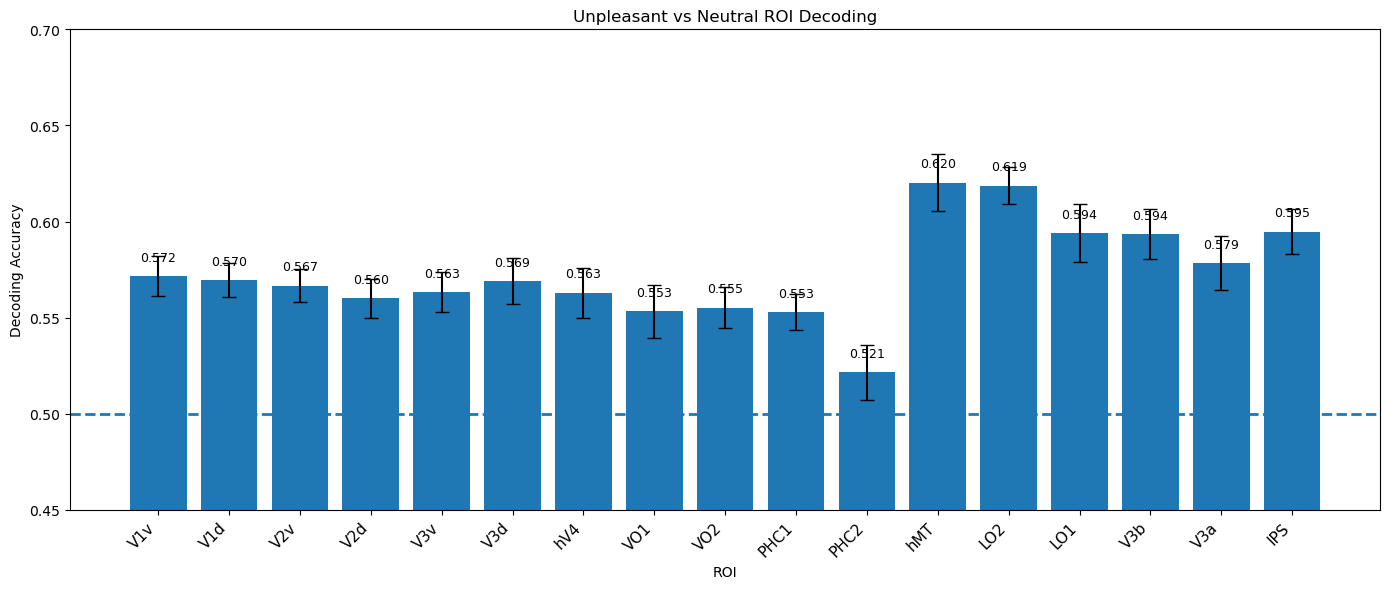

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ORIGINAL ROI ORDER
# ============================================================
roi_order = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d',
    'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2',
    'hMT', 'LO2', 'LO1', 'V3b', 'V3a',
    'IPS'
]

# ============================================================
# REORDER DATAFRAME
# ============================================================
plot_df = (
    summary_df
    .set_index("roi")
    .loc[roi_order]
    .reset_index()
)

# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(14, 6))

x = np.arange(len(plot_df))

plt.bar(
    x,
    plot_df["mean_accuracy"],
    yerr=plot_df["sem_accuracy"],
    capsize=5
)

# Chance line
plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2
)

# X labels
plt.xticks(
    x,
    plot_df["roi"],
    rotation=45,
    ha="right",
    fontsize=11
)

plt.ylabel("Decoding Accuracy")
plt.xlabel("ROI")
plt.title("Unpleasant vs Neutral ROI Decoding")

# ============================================================
# ADD ACCURACY VALUES
# ============================================================
for i, row in enumerate(plot_df.itertuples()):

    plt.text(
        i,
        row.mean_accuracy + 0.008,
        f"{row.mean_accuracy:.3f}",
        ha="center",
        fontsize=9
    )

plt.ylim(0.45, 0.70)

plt.tight_layout()

plt.savefig(
    "unpleasant_vs_neutral_roi_decoding_ordered.png",
    dpi=300
)

plt.show()